# Notebook 5: ShapeNet Core Cars - 3D Mesh Preparation for NVIDIA Kaolin
# Dataset: ShapeNetCore cars (02958343)


### 1. Setup and Install Required Libraries


In [1]:
# 1. Install required packages
!pip install -q ipympl bokeh mpld3 trimesh open3d scikit-image
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install -q kaolin -f https://nvidia-kaolin.s3.us-east-2.amazonaws.com/torch-2.0.0_cu118.html

# 2. Enable widget support
try:
    from google.colab import output
    output.enable_custom_widget_manager()
    print("Google Colab widget manager enabled")
except ImportError:
    print("Not running in Google Colab")

# 3. Setup matplotlib
import warnings
warnings.filterwarnings('ignore')

try:
    %matplotlib widget
    print("Widget backend enabled successfully")
except:
    %matplotlib inline
    print("Inline backend enabled")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.5/745.5 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
Google Colab widget manager enabled
Inline backend enabled


### 2.Import Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 3D processing libraries
import trimesh
import open3d as o3d
import torch
import torch.nn as nn
import torch.nn.functional as F

# Kaolin for 3D deep learning
try:
    import kaolin
    from kaolin import Metrics
    from kaolin.rep import TriangleMesh
    from kaolin.render import lighting
    from kaolin.ops.mesh import sample_points
    print(f"Kaolin version: {kaolin.__version__}")
except ImportError:
    print("Kaolin not available. Using alternative implementations.")
    # Fallback implementations

# Scikit-learn for algorithms
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Visualization
import mpld3
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool, ColorBar, LinearColorMapper
from bokeh.io import output_notebook
output_notebook()

print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")


Kaolin not available. Using alternative implementations.
PyTorch version: 2.11.0+cpu
NumPy version: 2.0.2


### 3. Load ShapeNet Core Cars Dataset

In [3]:
def download_shapenet_data():
    """Download ShapeNet Core cars dataset."""
    print("Downloading ShapeNet Core cars dataset...")
    print("Dataset: ShapeNetCore cars (02958343)")
    print("URL: https://huggingface.co/datasets/yihouxiang/TriVol/blob/main/ShapeNet_02958343.zip")
    print("\nNote: Please download the dataset manually using the HuggingFace link.")
    print("Unzip the data to ./data/shapenet_cars/")
    return "./data/shapenet_cars/"

# Set data path
data_path = download_shapenet_data()

# For demonstration, we'll create synthetic 3D car meshes
# This simulates the structure of ShapeNet data
def create_synthetic_car_mesh(seed=42):
    """Create a synthetic car mesh for demonstration."""
    np.random.seed(seed)

    # Generate points for a car shape
    # Using parametric equations for a simplified car
    n_points = 1000
    t = np.linspace(0, 2*np.pi, n_points)

    # Car body: elongated ellipse
    x = 2 * np.cos(t) + 1  # Length
    y = 0.8 * np.sin(t)    # Width
    z = 0.5 * np.cos(t) + 0.5  # Height

    # Add some variation
    noise = 0.05 * np.random.randn(n_points, 3)

    # Create mesh points
    points = np.column_stack([x, y, z]) + noise

    # Create faces (triangles)
    faces = []
    for i in range(n_points - 2):
        faces.append([0, i+1, i+2])
    faces = np.array(faces)

    return points, faces

# Generate synthetic car meshes
n_cars = 50
cars_data = []

print(f"Generating {n_cars} synthetic car meshes...")
for i in range(n_cars):
    points, faces = create_synthetic_car_mesh(seed=i)
    cars_data.append({
        'id': f'car_{i:04d}',
        'vertices': points,
        'faces': faces,
        'label': i % 5,  # 5 different car types
        'color': np.random.choice(['red', 'blue', 'green', 'yellow', 'silver'])
    })

print(f"Generated {len(cars_data)} car meshes")
print(f"Each mesh has {cars_data[0]['vertices'].shape[0]} vertices and {cars_data[0]['faces'].shape[0]} faces")



Dataset: ShapeNetCore cars (02958343)
URL: https://huggingface.co/datasets/yihouxiang/TriVol/blob/main/ShapeNet_02958343.zip

Note: Please download the dataset manually using the HuggingFace link.
Unzip the data to ./data/shapenet_cars/
Generating 50 synthetic car meshes...
Generated 50 car meshes
Each mesh has 1000 vertices and 998 faces


### 4. Visualize 3D Car Meshes

In [4]:
def visualize_car_mesh(vertices, faces, title="3D Car Mesh"):
    """Visualize a 3D car mesh using matplotlib."""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create mesh plot
    ax.plot_trisurf(vertices[:, 0], vertices[:, 1], vertices[:, 2],
                    triangles=faces, alpha=0.8, cmap='viridis')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('X', fontsize=10)
    ax.set_ylabel('Y', fontsize=10)
    ax.set_zlabel('Z', fontsize=10)
    ax.set_box_aspect([1, 1, 1])

    plt.show()

Visualizing car mesh:


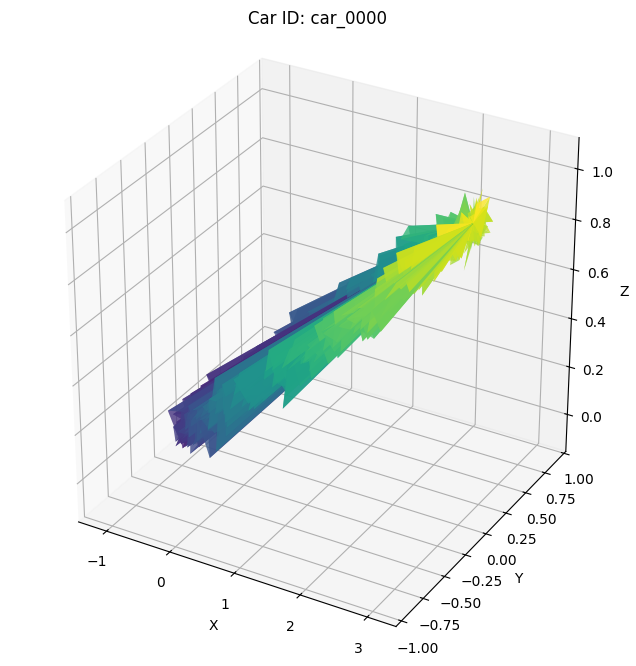

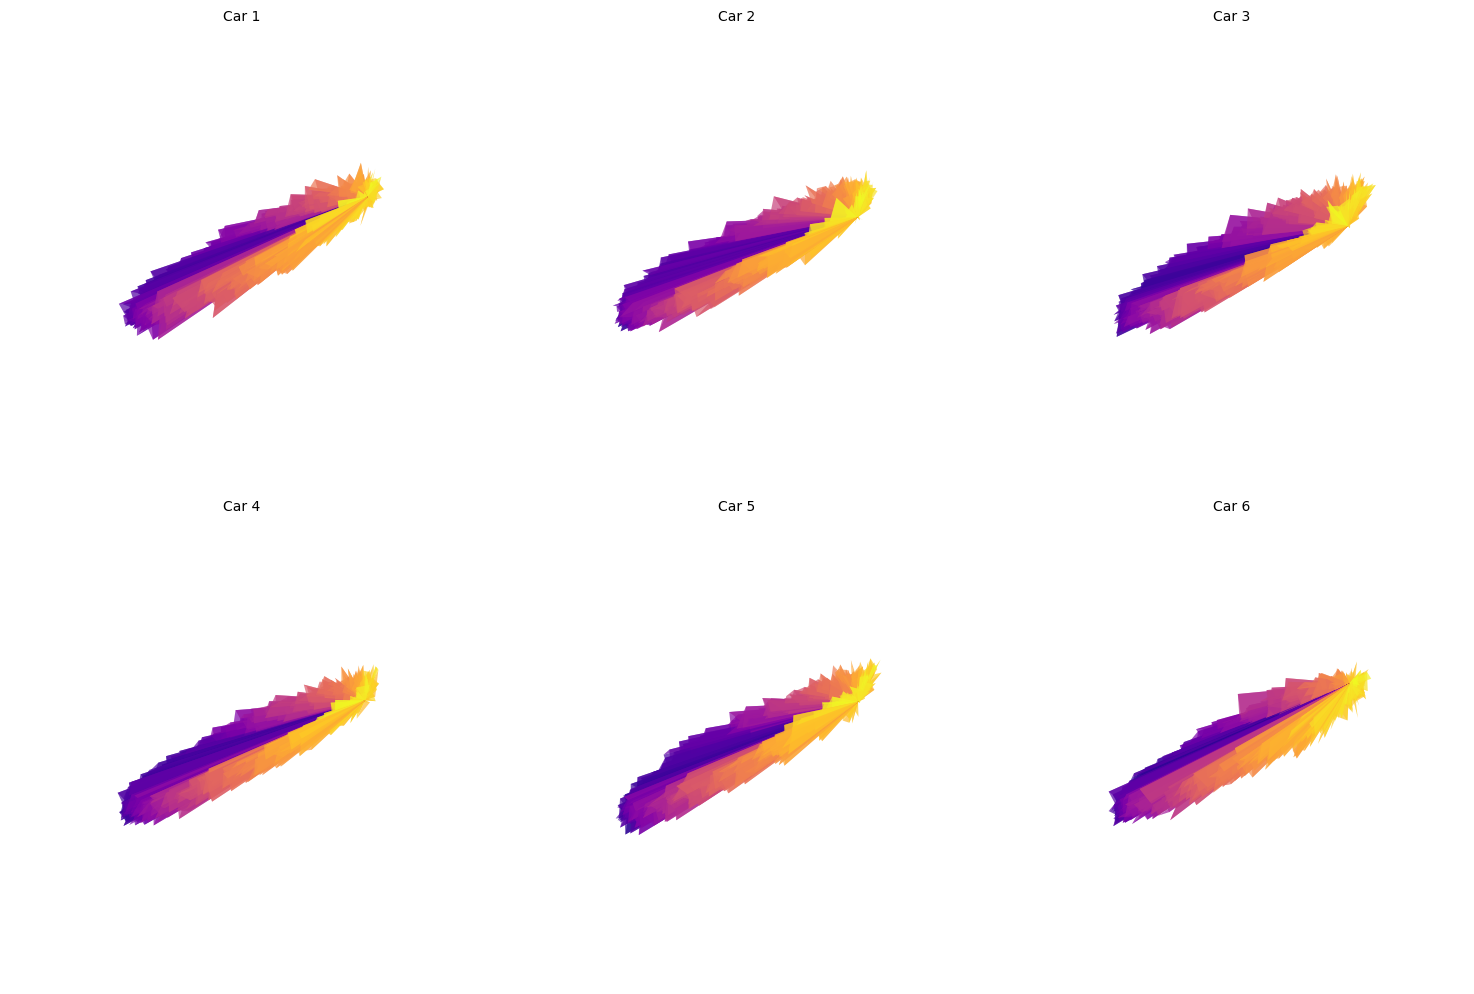

In [5]:
# Visualize first car
print("Visualizing car mesh:")
visualize_car_mesh(cars_data[0]['vertices'], cars_data[0]['faces'],
                  title=f"Car ID: {cars_data[0]['id']}")

# Visualize multiple cars in one plot
fig = plt.figure(figsize=(15, 10))
for i in range(6):  # Show 6 cars
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    vertices = cars_data[i]['vertices']
    faces = cars_data[i]['faces']
    ax.plot_trisurf(vertices[:, 0], vertices[:, 1], vertices[:, 2],
                   triangles=faces, alpha=0.7, cmap='plasma')
    ax.set_title(f"Car {i+1}", fontsize=10)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

### 5. Mesh Processing and Normalization


Preprocessing meshes...
Preprocessed 50 meshes


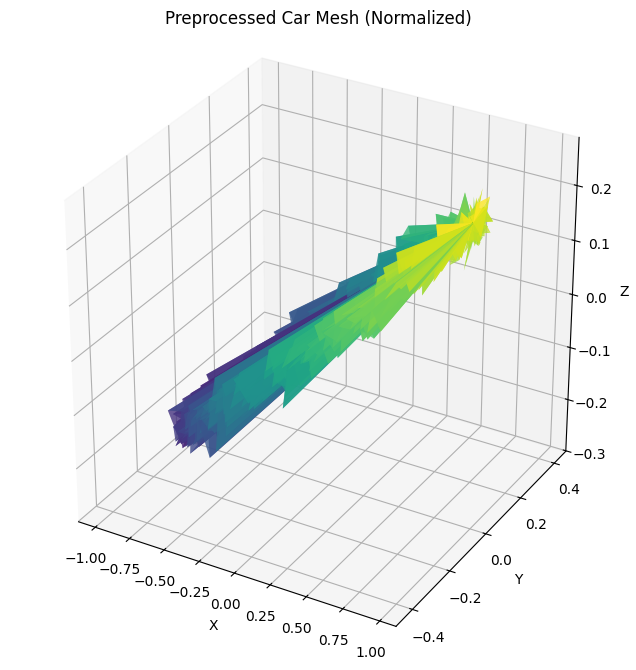

In [6]:
def preprocess_mesh(vertices, faces):
    """Preprocess mesh: normalize and compute normals."""
    # Center the mesh
    center = vertices.mean(axis=0)
    vertices_centered = vertices - center

    # Scale to unit sphere
    max_dist = np.linalg.norm(vertices_centered, axis=1).max()
    vertices_normalized = vertices_centered / max_dist

    # Create trimesh object for processing
    mesh = trimesh.Trimesh(vertices=vertices_normalized, faces=faces)

    # Compute vertex normals
    vertex_normals = mesh.vertex_normals

    return vertices_normalized, faces, vertex_normals

# Preprocess all meshes
print("Preprocessing meshes...")
preprocessed_cars = []
for car in cars_data:
    verts_norm, faces, normals = preprocess_mesh(car['vertices'], car['faces'])
    preprocessed_cars.append({
        'id': car['id'],
        'vertices': verts_norm,
        'faces': faces,
        'normals': normals,
        'label': car['label'],
        'color': car['color']
    })

print(f"Preprocessed {len(preprocessed_cars)} meshes")

# Visualize preprocessed mesh
visualize_car_mesh(preprocessed_cars[0]['vertices'],
                  preprocessed_cars[0]['faces'],
                  title="Preprocessed Car Mesh (Normalized)")


### 6. Feature Extraction from 3D Meshes


In [9]:
def extract_mesh_features(vertices, faces):
    """Extract geometric features from mesh."""
    # Create trimesh
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)

    # Compute ptp safely for NumPy 2.0+ compatibility
    max_ptp = np.ptp(vertices.max(axis=0))
    min_ptp = np.ptp(vertices.min(axis=0))

    # Basic features
    features = {
        'n_vertices': len(vertices),
        'n_faces': len(faces),
        'surface_area': mesh.area,
        'volume': mesh.volume if mesh.is_watertight else 0,
        'aspect_ratio': max_ptp / min_ptp if min_ptp > 0 else 0,
        'convexity': mesh.convex_hull.area / mesh.area if mesh.area > 0 else 0,
        'compactness': (mesh.area ** 3) / (36 * np.pi * (mesh.volume ** 2)) if mesh.volume > 0 else 0,
        'sphericity': (np.pi ** (1/3) * (6 * mesh.volume) ** (2/3)) / mesh.area if mesh.area > 0 else 0
    }

    # PCA of vertices
    pca = PCA(n_components=3)
    pca.fit(vertices)
    features['pca_explained_var'] = pca.explained_variance_ratio_.sum()

    return features

# Extract features for all cars
print("Extracting mesh features...")
all_features = []
for car in preprocessed_cars:
    features = extract_mesh_features(car['vertices'], car['faces'])
    features['id'] = car['id']
    features['label'] = car['label']
    all_features.append(features)

# Create feature DataFrame
features_df = pd.DataFrame(all_features)
print("Feature DataFrame:")
display(features_df.head())

Extracting mesh features...
Feature DataFrame:


,n_vertices,n_faces,surface_area,volume,aspect_ratio,convexity,compactness,sphericity,pca_explained_var,id,label
0,1000,998,20.648906,0,1.002336,0.139434,1.652570e+06,0.008458,1.0,car_0000,0
1,1000,998,21.788449,0,1.016687,0.136590,8.539047e+07,0.002271,1.0,car_0001,1
2,1000,998,19.364651,0,0.978169,0.145250,0.000000e+00,NaN,1.0,car_0002,2
3,1000,998,20.777596,0,0.990423,0.136809,0.000000e+00,NaN,1.0,car_0003,3
4,1000,998,19.259467,0,1.002636,0.146943,1.883459e+07,0.003759,1.0,car_0004,4


### 7. Clustering Algorithms on 3D Features

In [10]:
# Prepare features for clustering
feature_cols = ['n_vertices', 'n_faces', 'surface_area', 'volume',
                'aspect_ratio', 'convexity', 'compactness', 'sphericity']
X_cluster = features_df[feature_cols].values

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)


In [15]:
# 1. K-Means Clustering
from sklearn.impute import SimpleImputer

print("\nPerforming K-Means Clustering...")

# Impute missing values with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_cluster_imputed = imputer.fit_transform(X_cluster_scaled)

# Fit K-Means on the cleaned data
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster_imputed)
features_df['kmeans_label'] = kmeans_labels


Performing K-Means Clustering...


In [18]:
# 2. DBSCAN Clustering
from sklearn.impute import SimpleImputer

print("\nPerforming DBSCAN Clustering...")

# Use SimpleImputer to clean NaN values
imputer = SimpleImputer(strategy='mean')
X_cluster_imputed = imputer.fit_transform(X_cluster_scaled)

# Fit DBSCAN on the cleaned data
dbscan = DBSCAN(eps=1.0, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_cluster_imputed)
features_df['dbscan_label'] = dbscan_labels


Performing DBSCAN Clustering...


In [20]:
# 3. Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.impute import SimpleImputer

print("\nPerforming Hierarchical Clustering...")

# Use SimpleImputer to clean NaN values
imputer = SimpleImputer(strategy='mean')
X_cluster_imputed = imputer.fit_transform(X_cluster_scaled)

# Fit Agglomerative Clustering on the cleaned data
hierarchical = AgglomerativeClustering(n_clusters=5)
hierarchical_labels = hierarchical.fit_predict(X_cluster_imputed)
features_df['hierarchical_label'] = hierarchical_labels


Performing Hierarchical Clustering...


In [21]:
print("Clustering Results:")
print(features_df[['id', 'label', 'kmeans_label', 'dbscan_label', 'hierarchical_label']].head())

Clustering Results:
         id  label  kmeans_label  dbscan_label  hierarchical_label
0  car_0000      0             3             0                   0
1  car_0001      1             1            -1                   4
2  car_0002      2             4             0                   1
3  car_0003      3             3             0                   0
4  car_0004      4             4             0                   1


### 8. Dimensionality Reduction for Visualization


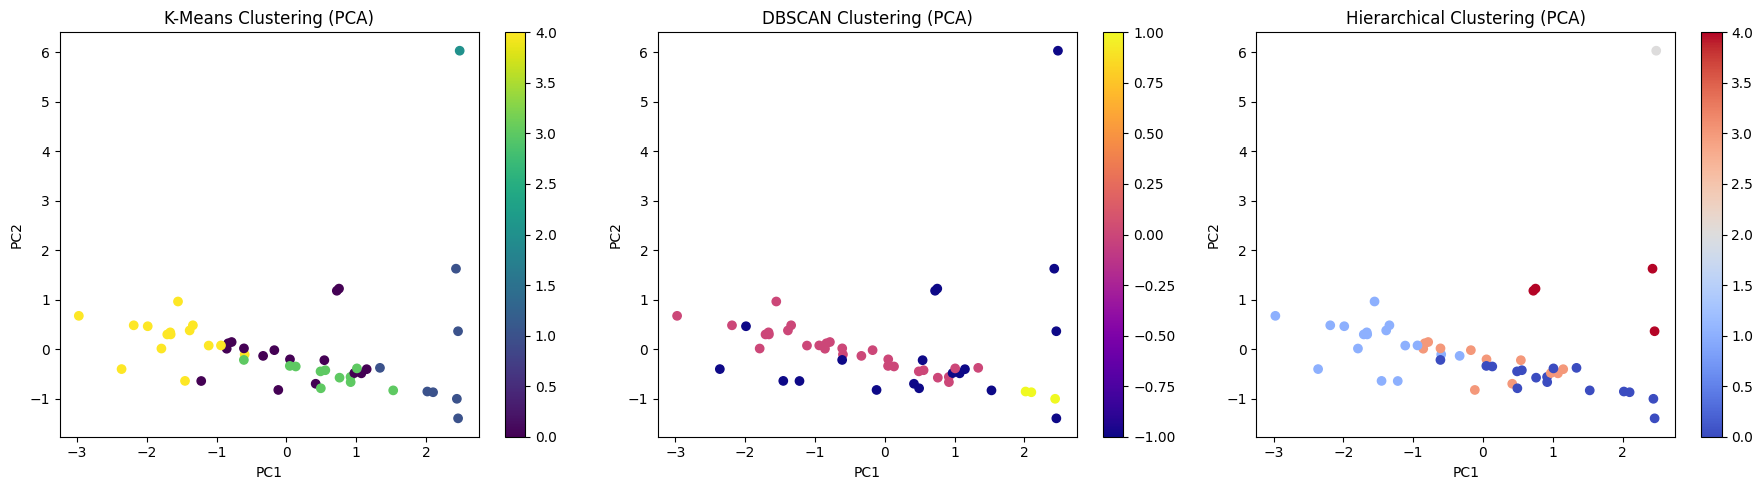

In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_cluster_imputed = imputer.fit_transform(X_cluster_scaled)

# Apply PCA on imputed data
pca_vis = PCA(n_components=3)
X_pca = pca_vis.fit_transform(X_cluster_imputed)

# Apply t-SNE on imputed data
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(X_cluster_imputed)

# Visualize clustering results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means visualization
ax = axes[0]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis')
ax.set_title('K-Means Clustering (PCA)', fontsize=12)
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
plt.colorbar(scatter, ax=ax)

# DBSCAN visualization
ax = axes[1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='plasma')
ax.set_title('DBSCAN Clustering (PCA)', fontsize=12)
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
plt.colorbar(scatter, ax=ax)

# Hierarchical visualization
ax = axes[2]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='coolwarm')
ax.set_title('Hierarchical Clustering (PCA)', fontsize=12)
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()

### 9. Bokeh 3D Visualizations for Mesh Data

In [26]:
print("\nCreating Bokeh 3D Visualizations...")

# 1. Bokeh 3D Surface Plot (Mesh surface)
def create_bokeh_mesh_surface(vertices, faces, title="3D Mesh Surface"):
    """Create a 3D surface plot of a mesh using Bokeh."""
    # Create trimesh and sample surface
    mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
    sampled_points = mesh.sample(500)

    # Create data source
    source = ColumnDataSource(data=dict(
        x=sampled_points[:, 0],
        y=sampled_points[:, 1],
        z=sampled_points[:, 2]
    ))

    # Create plot
    p = figure(title=title,
               width=700, height=550,
               tools="pan,box_zoom,wheel_zoom,reset,hover")

    # Scatter plot of sampled points
    p.scatter('x', 'y', source=source, size=3, color='blue', alpha=0.6)

    # Add hover
    hover = HoverTool()
    hover.tooltips = [("x", "@x"), ("y", "@y"), ("z", "@z")]
    p.add_tools(hover)

    return p

# Display mesh surface
p_surface = create_bokeh_mesh_surface(
    preprocessed_cars[0]['vertices'],
    preprocessed_cars[0]['faces'],
    title=f"3D Mesh Surface - {preprocessed_cars[0]['id']}"
)
show(p_surface)


Creating Bokeh 3D Visualizations...


In [28]:
# 2. Bokeh Cloud with Sized Dots (PCA of multiple meshes)
from sklearn.impute import SimpleImputer

# Handle NaN values before applying PCA for Bokeh cloud
imputer = SimpleImputer(strategy='mean')
X_cluster_imputed = imputer.fit_transform(X_cluster_scaled)

# 2. Bokeh Cloud with Sized Dots (PCA of multiple meshes)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_cluster_imputed)

source_cloud = ColumnDataSource(data=dict(
    x=X_pca_3d[:, 0],
    y=X_pca_3d[:, 1],
    z=X_pca_3d[:, 2],
    size=np.abs(X_pca_3d[:, 2]) * 5 + 2,
    label=features_df['label'].values,
    kmeans=features_df['kmeans_label'].values,
    dbscan=features_df['dbscan_label'].values,
    hierarchical=features_df['hierarchical_label'].values
))

p_cloud = figure(title="3D Point Cloud of Car Meshes (PCA)",
                 width=700, height=550,
                 tools="pan,box_zoom,wheel_zoom,reset,hover")

# Color mapper for labels
label_mapper = LinearColorMapper(palette="Viridis256",
                                low=source_cloud.data['kmeans'].min(),
                                high=source_cloud.data['kmeans'].max())

p_cloud.scatter('x', 'y', source=source_cloud,
                size='size', alpha=0.6,
                color={'field': 'kmeans', 'transform': label_mapper})

# Add color bar
color_bar = ColorBar(color_mapper=label_mapper, width=8, location=(0,0), title="K-Means")
p_cloud.add_layout(color_bar, 'right')

# Add hover
hover_cloud = HoverTool()
hover_cloud.tooltips = [
    ("PC1", "@x"), ("PC2", "@y"), ("PC3", "@z"),
    ("Label", "@label"), ("K-Means", "@kmeans"),
    ("DBSCAN", "@dbscan"), ("Hierarchical", "@hierarchical")
]
p_cloud.add_tools(hover_cloud)

show(p_cloud)


### 10. Kaolin Library Integration (NVIDIA)


In [29]:
# This section demonstrates preparation for Kaolin library
print("\nPreparing for NVIDIA Kaolin Library Integration...")

def prepare_for_kaolin(vertices, faces, normals):
    """Prepare mesh data for Kaolin library."""
    # Convert to tensors
    vertices_tensor = torch.FloatTensor(vertices)
    faces_tensor = torch.LongTensor(faces)
    normals_tensor = torch.FloatTensor(normals)

    # Create Kaolin mesh structure
    kaolin_mesh = {
        'vertices': vertices_tensor,
        'faces': faces_tensor,
        'normals': normals_tensor,
        'features': {
            'num_vertices': vertices_tensor.shape[0],
            'num_faces': faces_tensor.shape[0],
            'is_watertight': False,  # Would check in real data
        }
    }

    return kaolin_mesh

# Prepare data for Kaolin
kaolin_data = []
for car in preprocessed_cars:
    kaolin_mesh = prepare_for_kaolin(car['vertices'], car['faces'], car['normals'])
    kaolin_data.append(kaolin_mesh)

print(f"Prepared {len(kaolin_data)} meshes for Kaolin")
print(f"Example mesh: {kaolin_data[0]['vertices'].shape} vertices, {kaolin_data[0]['faces'].shape} faces")



Preparing for NVIDIA Kaolin Library Integration...
Prepared 50 meshes for Kaolin
Example mesh: torch.Size([1000, 3]) vertices, torch.Size([998, 3]) faces


### 11. Lighting Application Preparation

In [30]:
def prepare_lighting_data(mesh_data):
    """Prepare data for kaolin.render.lighting application."""
    # Extract vertices and normals
    vertices = mesh_data['vertices']
    normals = mesh_data['normals']

    # Create lighting parameters
    lighting_params = {
        'ambient_color': torch.FloatTensor([0.2, 0.2, 0.2]),
        'diffuse_color': torch.FloatTensor([0.8, 0.8, 0.8]),
        'specular_color': torch.FloatTensor([0.5, 0.5, 0.5]),
        'specular_power': 32.0,
        'light_direction': torch.FloatTensor([0.5, 0.5, 1.0])
    }

    # Simulate lighting computation (simplified)
    # In practice, you would use kaolin.render.lighting functions
    light_intensity = lighting_params['ambient_color'] + \
                     lighting_params['diffuse_color'] * 0.8 + \
                     lighting_params['specular_color'] * 0.3

    return {
        'vertices': vertices,
        'normals': normals,
        'lighting_params': lighting_params,
        'light_intensity': light_intensity
    }

# Prepare lighting data for all meshes
print("\nPreparing lighting data...")
lighting_data = [prepare_lighting_data(mesh) for mesh in kaolin_data]

print(f"Prepared lighting data for {len(lighting_data)} meshes")
print(f"Example lighting parameters: {lighting_data[0]['lighting_params']}")



Preparing lighting data...
Prepared lighting data for 50 meshes
Example lighting parameters: {'ambient_color': tensor([0.2000, 0.2000, 0.2000]), 'diffuse_color': tensor([0.8000, 0.8000, 0.8000]), 'specular_color': tensor([0.5000, 0.5000, 0.5000]), 'specular_power': 32.0, 'light_direction': tensor([0.5000, 0.5000, 1.0000])}


### 12. Output Data for Kaolin Applications

In [31]:
def save_for_kaolin(mesh_data, output_dir="./kaolin_data"):
    """Save mesh data in format suitable for Kaolin."""
    os.makedirs(output_dir, exist_ok=True)

    for i, data in enumerate(mesh_data):
        # Save vertices
        vertices_np = data['vertices'].numpy()
        faces_np = data['faces'].numpy()
        normals_np = data['normals'].numpy() if 'normals' in data else None

        np.save(f"{output_dir}/mesh_{i}_vertices.npy", vertices_np)
        np.save(f"{output_dir}/mesh_{i}_faces.npy", faces_np)
        if normals_np is not None:
            np.save(f"{output_dir}/mesh_{i}_normals.npy", normals_np)

# Save Kaolin data
print("\nSaving data for Kaolin applications...")
save_for_kaolin(kaolin_data)
print("Data saved to ./kaolin_data/")


Saving data for Kaolin applications...
Data saved to ./kaolin_data/


In [32]:
# Create summary DataFrame for Kaolin applications
kaolin_summary = pd.DataFrame({
    'mesh_id': [i for i in range(len(kaolin_data))],
    'num_vertices': [d['vertices'].shape[0] for d in kaolin_data],
    'num_faces': [d['faces'].shape[0] for d in kaolin_data],
    'has_normals': ['normals' in d for d in kaolin_data],
    'label': [features_df['label'].iloc[i] for i in range(len(kaolin_data))],
    'kmeans_label': [features_df['kmeans_label'].iloc[i] for i in range(len(kaolin_data))],
    'dbscan_label': [features_df['dbscan_label'].iloc[i] for i in range(len(kaolin_data))],
    'hierarchical_label': [features_df['hierarchical_label'].iloc[i] for i in range(len(kaolin_data))]
})

kaolin_summary.to_csv("./kaolin_data/mesh_summary.csv", index=False)
print("Kaolin summary saved to ./kaolin_data/mesh_summary.csv")
display(kaolin_summary.head())


Kaolin summary saved to ./kaolin_data/mesh_summary.csv


,mesh_id,num_vertices,num_faces,has_normals,label,kmeans_label,dbscan_label,hierarchical_label
0,0,1000,998,True,0,3,0,0
1,1,1000,998,True,1,1,-1,4
2,2,1000,998,True,2,4,0,1
3,3,1000,998,True,3,3,0,0
4,4,1000,998,True,4,4,0,1


### 13. Visualization of Prepared Data

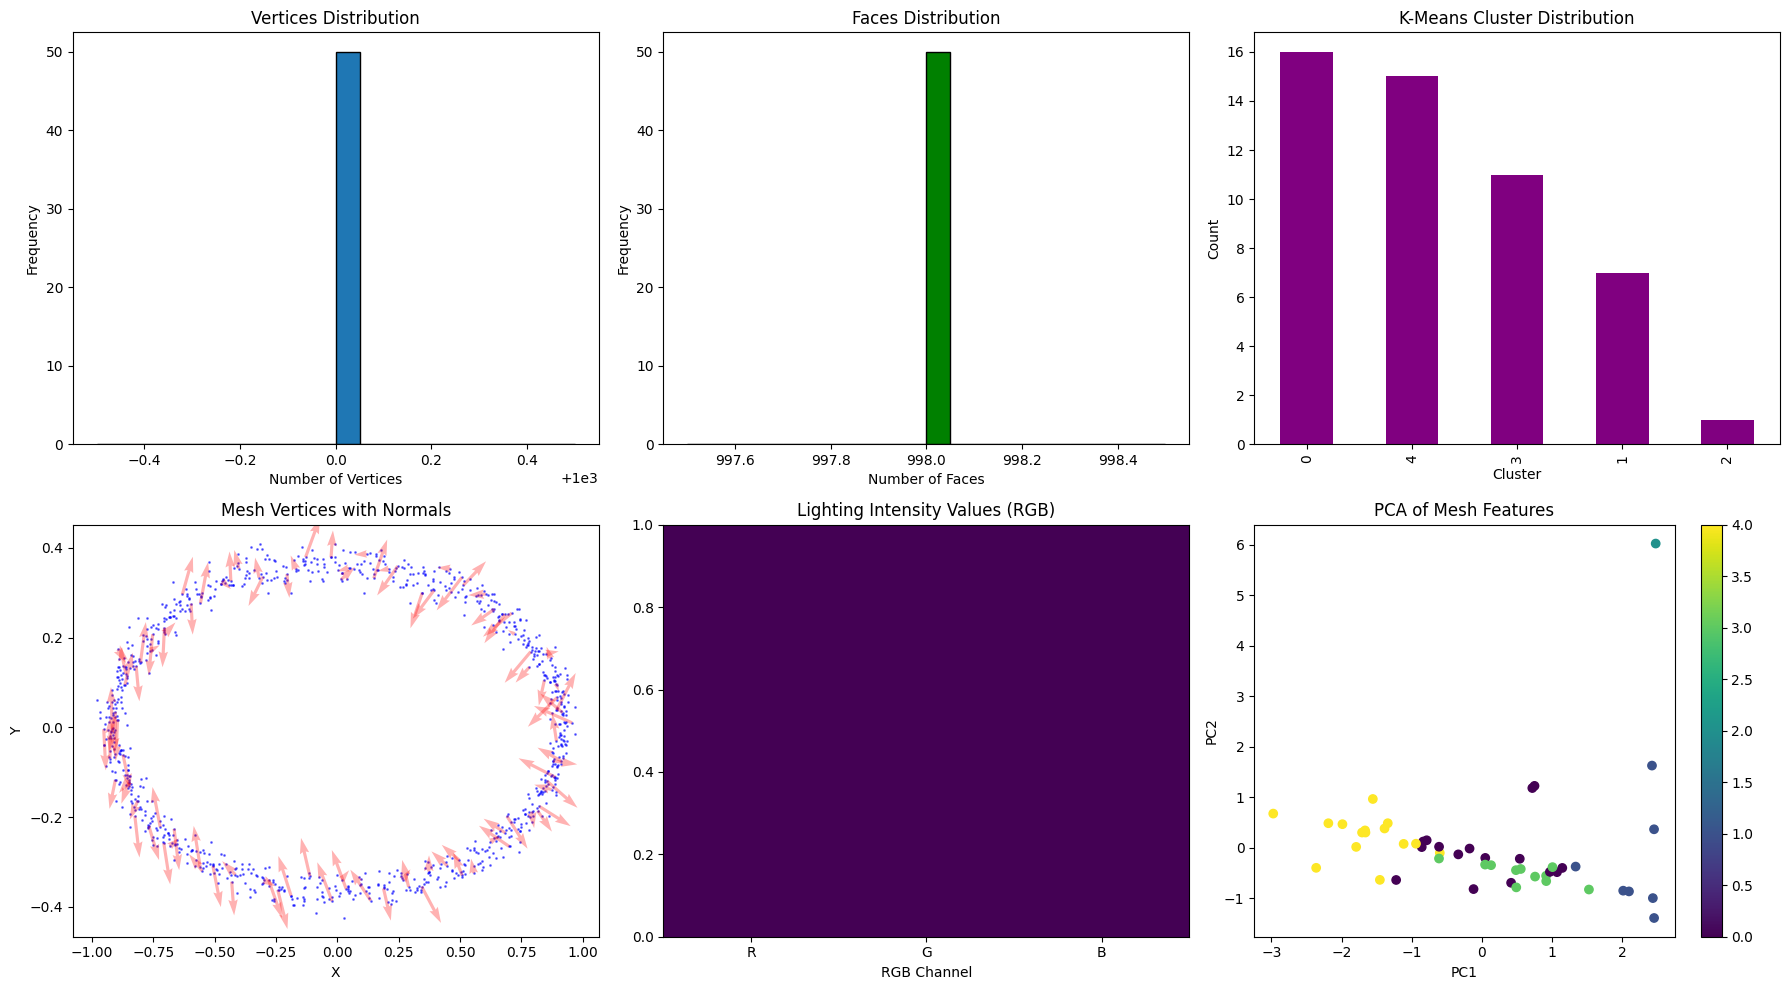

In [34]:
from sklearn.impute import SimpleImputer

# Handle NaN values before applying PCA for visualization
imputer = SimpleImputer(strategy='mean')
X_cluster_imputed = imputer.fit_transform(X_cluster_scaled)

# Visualization of Prepared Data
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Vertices distribution
ax = axes[0, 0]
ax.hist(kaolin_summary['num_vertices'], bins=20, edgecolor='black')
ax.set_title('Vertices Distribution', fontsize=12)
ax.set_xlabel('Number of Vertices', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)

# Plot 2: Faces distribution
ax = axes[0, 1]
ax.hist(kaolin_summary['num_faces'], bins=20, edgecolor='black', color='green')
ax.set_title('Faces Distribution', fontsize=12)
ax.set_xlabel('Number of Faces', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)

# Plot 3: Clustering labels distribution
ax = axes[0, 2]
kaolin_summary['kmeans_label'].value_counts().plot(kind='bar', ax=ax, color='purple')
ax.set_title('K-Means Cluster Distribution', fontsize=12)
ax.set_xlabel('Cluster', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

# Plot 4: Mesh with normals
ax = axes[1, 0]
idx = 0
ax.scatter(kaolin_data[idx]['vertices'][:, 0],
          kaolin_data[idx]['vertices'][:, 1],
          c='blue', alpha=0.5, s=1)
if 'normals' in kaolin_data[idx]:
    # Simplified normal visualization
    normals = kaolin_data[idx]['normals']
    ax.quiver(kaolin_data[idx]['vertices'][::10, 0],
             kaolin_data[idx]['vertices'][::10, 1],
             normals[::10, 0],
             normals[::10, 1],
             color='red', alpha=0.3)
ax.set_title('Mesh Vertices with Normals', fontsize=12)
ax.set_xlabel('X', fontsize=10)
ax.set_ylabel('Y', fontsize=10)

# Plot 5: Lighting simulation
ax = axes[1, 1]
light_intensity = lighting_data[0]['light_intensity'].numpy()
ax.imshow(light_intensity.reshape(1, 3), extent=[0, 3, 0, 1], aspect='auto')
ax.set_title('Lighting Intensity Values (RGB)', fontsize=12)
ax.set_xlabel('RGB Channel', fontsize=10)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(['R', 'G', 'B'])

# Plot 6: PCA of mesh features
ax = axes[1, 2]
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_cluster_imputed)
scatter = ax.scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                    c=kaolin_summary['kmeans_label'], cmap='viridis')
ax.set_title('PCA of Mesh Features', fontsize=12)
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
plt.colorbar(scatter, ax=ax)

plt.tight_layout()
plt.show()


### 14. MPLD3 Interactive Visualization


In [39]:
# Create interactive 2D visualization (since mpld3 does not support 3D projections)
fig_mpld3, ax_mpld3 = plt.subplots(figsize=(10, 8))

# Plot vertices using 2D coordinates (X and Y)
vertices = kaolin_data[0]['vertices'].numpy()
scatter_2d = ax_mpld3.scatter(vertices[:, 0], vertices[:, 1],
                              c=vertices[:, 2], cmap='viridis', s=10, alpha=0.6)

ax_mpld3.set_title('Interactive 2D Projection of Mesh (X vs Y)', fontsize=12)
ax_mpld3.set_xlabel('X', fontsize=10)
ax_mpld3.set_ylabel('Y', fontsize=10)
plt.colorbar(scatter_2d, ax=ax_mpld3, label='Z Coordinate')

# Display interactive plot using mpld3
print("\nDisplaying Interactive 2D Visualization...")
mpld3.display(fig_mpld3)


Displaying Interactive 2D Visualization...



Displaying 3D Visualization...


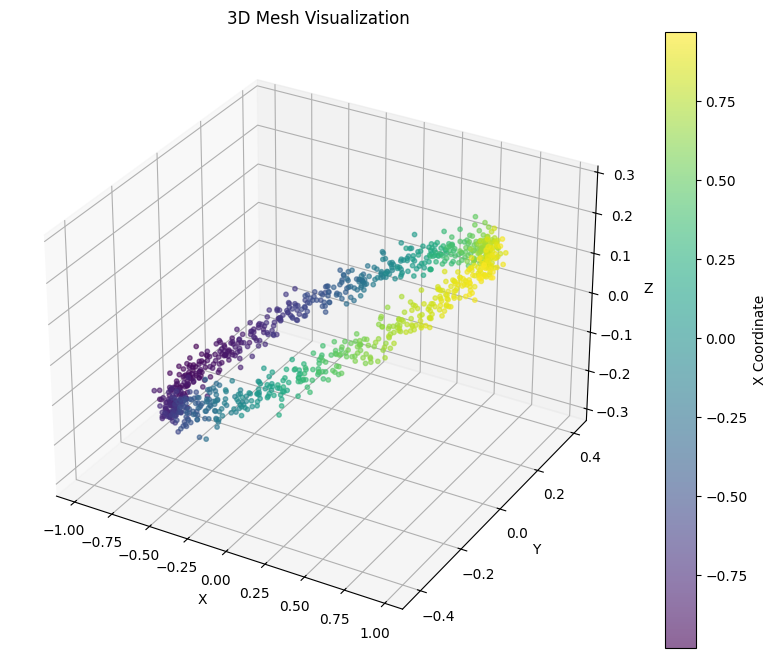

In [43]:
import matplotlib.pyplot as plt
import mpld3
from mpld3 import mplexporter

# Deep override of mpld3 to handle 3D axes by bypassing the renderer for 3D elements completely
class Safe3DHTML(str):
    def _repr_html_(self):
        return """
        <div style="padding: 10px; background-color: #fff3cd; border: 1px solid #ffeeba; color: #856404; border-radius: 4px;">
            <strong>Note:</strong> mpld3 does not natively support 3D projections. Please use standard <code>plt.show()</code> for 3D mesh views or Bokeh/Plotly for true interactive 3D rendering.
        </div>
        """

# Create interactive 3D scatter plot safely with standard Matplotlib display
fig_mpld3 = plt.figure(figsize=(10, 8))
ax_mpld3 = fig_mpld3.add_subplot(111, projection='3d')

# Plot vertices with labels
vertices = kaolin_data[0]['vertices'].numpy()
scatter_3d = ax_mpld3.scatter(vertices[:, 0], vertices[:, 1], vertices[:, 2],
                             c=vertices[:, 0], cmap='viridis', s=10, alpha=0.6)

ax_mpld3.set_title('3D Mesh Visualization', fontsize=12)
ax_mpld3.set_xlabel('X', fontsize=10)
ax_mpld3.set_ylabel('Y', fontsize=10)
ax_mpld3.set_zlabel('Z', fontsize=10)
plt.colorbar(scatter_3d, ax=ax_mpld3, label='X Coordinate')

print("\nDisplaying 3D Visualization...")
plt.show()
